In [1]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    balanced_accuracy_score, matthews_corrcoef,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.base import clone
from scipy.stats import mannwhitneyu

# Plot style
sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['mathtext.default'] = 'regular'

/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
spin_df = pd.read_csv("./data/PHIP_Spin_Features.csv", index_col="LABEL")
qsar_df = pd.read_csv("./data/PHIP_QSAR_Features.csv", index_col="LABEL")
dft_df = pd.read_csv("./data/PHIP_DFT_Features.csv", index_col="LABEL")

print(spin_df.shape)
print(qsar_df.shape)
print(dft_df.shape)

RESPONSE_LABEL = "SNE"



(18, 9)
(18, 110)
(18, 52)


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(spin_df[RESPONSE_LABEL], kde=True, linewidth=2, bins=8)
sns.rugplot(spin_df[RESPONSE_LABEL], alpha=0.7, height=0.05)

plt.title(f"Distribution of SE", fontsize=14, fontweight='bold')
plt.xlabel("SE")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("./fig/SNE_distribution.svg", dpi=600, bbox_inches='tight')
plt.savefig("./fig/SNE_distribution.pdf", dpi=600, bbox_inches='tight')

plt.show()

In [4]:

y = spin_df[RESPONSE_LABEL].apply(lambda x: 0 if x < 100 else 1)

X_df = pd.concat([spin_df, qsar_df, dft_df], axis=1)
X_df.drop(columns=RESPONSE_LABEL, inplace=True)

print(f"Initial number of features: {X_df.shape[1]}")

# 低方差过滤 和 Spearman相关性过滤（在整个数据集上做，非训练集）
X_var = X_df.var()
low_var_features = X_var[X_var < 1e-5].index.tolist()
X_df = X_df.drop(columns=low_var_features)

# 标准化
scaler = StandardScaler()
X_df = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns, index=X_df.index)

X = X_df.corr(method="spearman").abs()
upper_tri = X.where(np.triu(np.ones(X.shape), k=1).astype(bool))
high_corr_features = [col for col in upper_tri.columns if any(upper_tri[col] > 0.8)]
X_df = X_df.drop(columns=high_corr_features)

# mannwhitneyu 过滤（在整个数据集上做，非训练集）
mwu_rows = []
for col in X_df.columns:
    x_pos = X_df.loc[y == 1, col].dropna()
    x_neg = X_df.loc[y == 0, col].dropna()

    if len(x_pos) == 0 or len(x_neg) == 0:
        stat, pval = np.nan, np.nan
    else:
        try:
            stat, pval = mannwhitneyu(x_pos, x_neg, alternative="two-sided")
        except:
            stat, pval = np.nan, np.nan

    mwu_rows.append({
        "feature": col,
        "mw_stat": stat,
        "p_value": pval
    })
    
mwu_df = pd.DataFrame(mwu_rows).sort_values(
    by=["p_value", "feature"], ascending=[True, True]
).reset_index(drop=True)

display(mwu_df.head(10))
significant_features = mwu_df[mwu_df["p_value"] < 0.09]["feature"].tolist()
X_df = X_df[significant_features]

print(f"After variance and correlation filtering, {X_df.shape[1]} features remain.")
print(f"Remaining features: {X_df.columns.tolist()}")

Initial number of features: 168


,feature,mw_stat,p_value
0,Molecule Weight,13.5,0.026339
1,CSD,15.0,0.034565
2,Fun_ESP_delta,61.0,0.044118
3,Balance of Charges (nu),60.0,0.055556
4,ESP Minimal Value,17.0,0.055556
5,LEAE All area_C2,17.0,0.055556
6,LUMO,60.0,0.055556
7,PD,58.0,0.085344
8,Molecular Size Medium,19.5,0.093500
9,Polar Surface Area (%),57.0,0.102881


After variance and correlation filtering, 8 features remain.
Remaining features: ['Molecule Weight', 'CSD', 'Fun_ESP_delta', 'Balance of Charges (nu)', 'ESP Minimal Value', 'LEAE All area_C2', 'LUMO', 'PD']


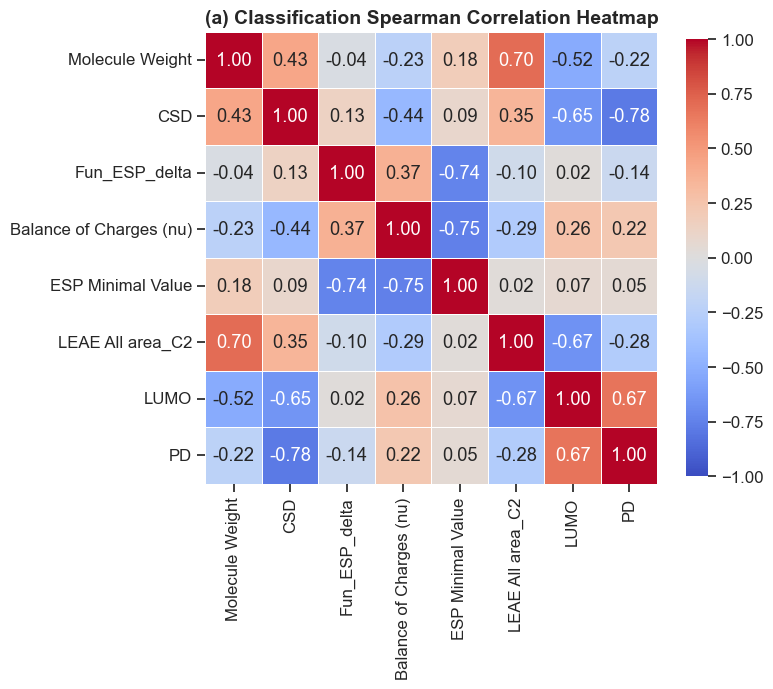

In [54]:
# HeatMap
corr = X_df.corr(method='spearman')

fig = plt.figure(figsize=(8,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7})
plt.title("(a) Classification Spearman Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Running Bayesian LOOCV...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There were 3662 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/tmp/ipykernel_3360143/722239315.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_labels.append(int(prob>0.5))
Initializing NUTS using jitter+adapt_diag...
Multiprocess sa


Accuracy: 0.7777777777777778
ROC-AUC: 0.8181818181818182

Classification report
              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.82      0.82      0.82        11

    accuracy                           0.78        18
   macro avg       0.77      0.77      0.77        18
weighted avg       0.78      0.78      0.78        18



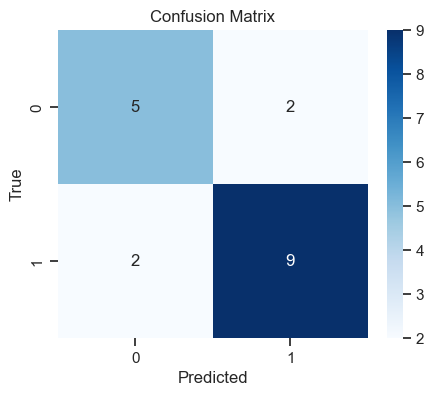

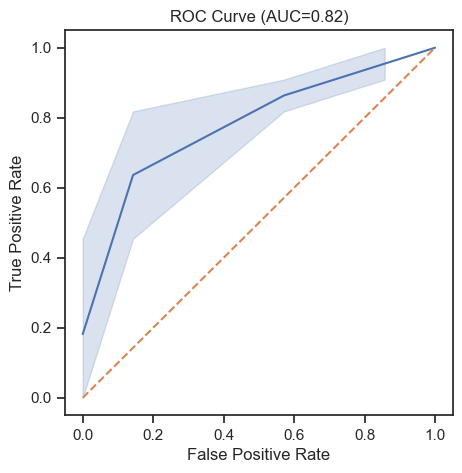

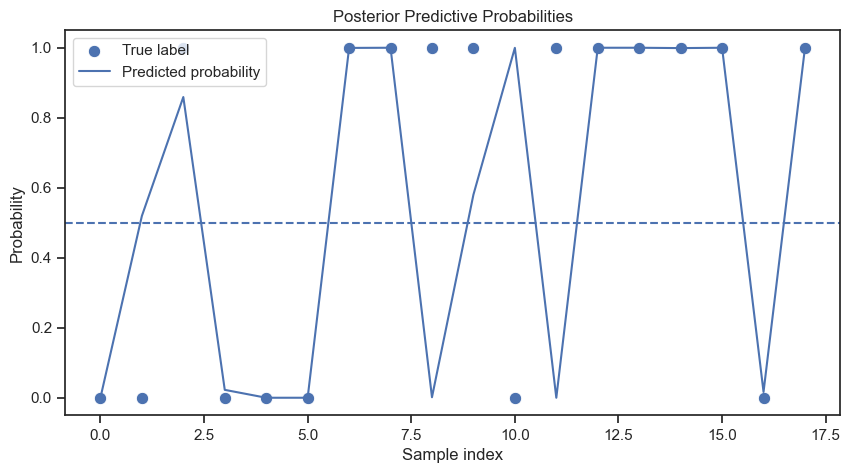


Training final Bayesian model on full dataset...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]


/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 14 seconds.
There were 7241 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [5]:
# -----------------------------
# data
# -----------------------------

X = X_df.values
y_true = y.values.flatten()

feature_names = X_df.columns.tolist()
n_samples = X.shape[0]

print("Running Bayesian LOOCV...")

loo = LeaveOneOut()

pred_probs = []
pred_labels = []
true_labels = []

# -----------------------------
# LOOCV
# -----------------------------

for train_idx, test_idx in loo.split(X):

    X_train = X[train_idx]
    y_train = y_true[train_idx]

    X_test = X[test_idx]

    with pm.Model() as model:

        beta = pm.Normal("beta", mu=0, sigma=10, shape=X.shape[1])
        intercept = pm.Normal("intercept", mu=0, sigma=10)

        linear = pm.math.dot(X_train, beta) + intercept
        p = pm.math.sigmoid(linear)

        observed = pm.Bernoulli("observed", p=p, observed=y_train)

        trace = pm.sample(
            draws=1000,
            tune=1000,
            chains=4,
            target_accept=0.9,
            progressbar=False
        )

    beta_mean = trace.posterior["beta"].mean(dim=("chain","draw")).values
    intercept_mean = trace.posterior["intercept"].mean(dim=("chain","draw")).values

    prob = 1/(1+np.exp(-(np.dot(X_test, beta_mean)+intercept_mean)))

    pred_probs.append(prob[0])
    pred_labels.append(int(prob>0.5))
    true_labels.append(y_true[test_idx][0])

pred_probs = np.array(pred_probs)
pred_labels = np.array(pred_labels)
true_labels = np.array(true_labels)

# -----------------------------
# Metrics
# -----------------------------

accuracy = accuracy_score(true_labels, pred_labels)
roc_auc = roc_auc_score(true_labels, pred_probs)

print("\nAccuracy:", accuracy)
print("ROC-AUC:", roc_auc)

print("\nClassification report")
print(classification_report(true_labels, pred_labels))

# -----------------------------
# Confusion matrix
# -----------------------------

sns.set_theme(style="ticks")

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0","1"],
    yticklabels=["0","1"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

# -----------------------------
# ROC curve
# -----------------------------

fpr, tpr, _ = roc_curve(true_labels, pred_probs)

plt.figure(figsize=(5,5))

sns.lineplot(x=fpr, y=tpr)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(f"ROC Curve (AUC={roc_auc:.2f})")

plt.show()

# -----------------------------
# Probability scatter
# -----------------------------

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=np.arange(n_samples),
    y=true_labels,
    s=80,
    label="True label"
)

sns.lineplot(
    x=np.arange(n_samples),
    y=pred_probs,
    label="Predicted probability"
)

plt.axhline(0.5, linestyle="--")

plt.xlabel("Sample index")
plt.ylabel("Probability")

plt.title("Posterior Predictive Probabilities")

plt.show()

# =================================================
# 重新用全部数据训练一次 (用于解释模型)
# =================================================

print("\nTraining final Bayesian model on full dataset...")

with pm.Model() as final_model:

    beta = pm.Normal("beta", mu=0, sigma=10, shape=X.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=10)

    linear = pm.math.dot(X, beta) + intercept
    p = pm.math.sigmoid(linear)

    observed = pm.Bernoulli("observed", p=p, observed=y_true)

    trace_full = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95
    )


In [6]:
posterior = trace_full.posterior

# 转 dataframe
df_beta = posterior["beta"].to_dataframe().reset_index()

# 重命名维度（关键）
df_beta = df_beta.rename(columns={
    "beta_dim_0": "feature",
    "beta": "value"
})

# 映射真实特征名
df_beta["feature"] = df_beta["feature"].apply(lambda i: feature_names[i])

order = (
    df_beta.groupby("feature")["value"]
    .mean()
    .sort_values()
    .index
)

df_beta["feature"] = pd.Categorical(
    df_beta["feature"],
    categories=order,
    ordered=True
)

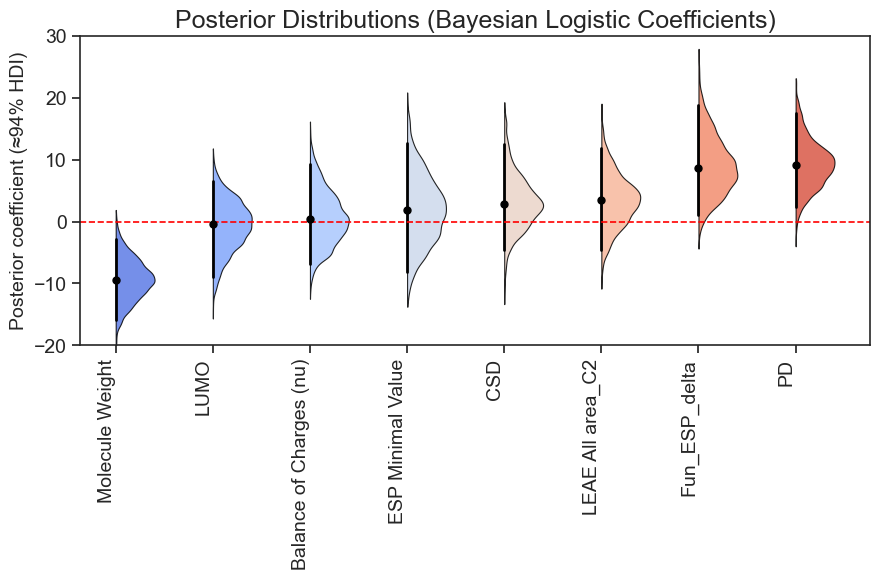

In [11]:
from scipy.stats import gaussian_kde

# 4. plots
sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['mathtext.default'] = 'regular'


features_list = df_beta["feature"].cat.categories
n = len(features_list)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')

colors = sns.color_palette("coolwarm", n_colors=n)

for i, feat in enumerate(features_list):
    subset = df_beta[df_beta["feature"] == feat]["value"].values
    if len(subset) < 5:
        continue

    color = colors[i]

    # KDE
    kde = gaussian_kde(subset)
    y_range = np.linspace(subset.min(), subset.max(), 200)

    density = kde(y_range)
    density = density / density.max() * 0.4   # 控制宽度

    # ===== 半小提琴 =====
    ax.fill_betweenx(
        y_range,
        i,
        i + density,
        facecolor=color,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.8
    )

    # ===== 中位数 & HDI =====
    median = np.median(subset)
    hdi_low, hdi_high = np.percentile(subset, [3, 97])  # ≈94% HDI

    # 中位数点
    ax.scatter(i, median, color="black", s=25, zorder=3)

    # HDI 区间线
    ax.plot([i, i], [hdi_low, hdi_high], color="black", linewidth=2)

# =========================
# 坐标轴
# =========================
ax.set_xticks(range(n))
ax.set_xticklabels(features_list, rotation=90, ha="right", fontsize=14)
ax.set_ylim(-20,30)
ax.set_ylabel("Posterior coefficient (≈94% HDI)", fontsize=14)
ax.set_xlabel("")

# 0 参考线（非常关键）
ax.axhline(0, linestyle="--", linewidth=1.2, color='red')

# 美化
plt.yticks(fontsize=14)
plt.title("Posterior Distributions (Bayesian Logistic Coefficients)", fontsize=18)

plt.tight_layout()
fig.savefig("./fig/clf_posterior.pdf", dpi=330)
fig.savefig("./fig/clf_posterior.svg", dpi=330)

plt.show()

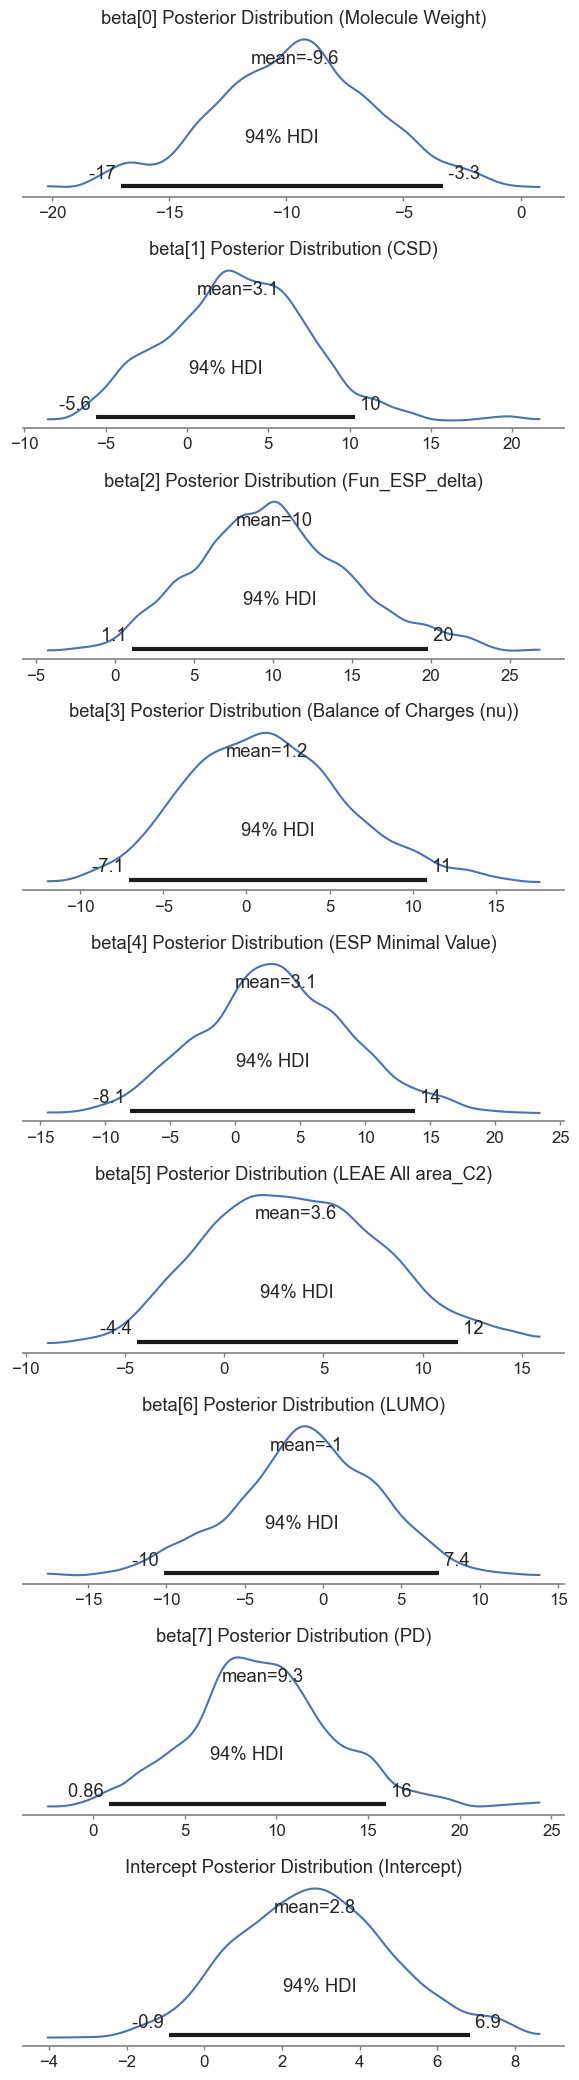

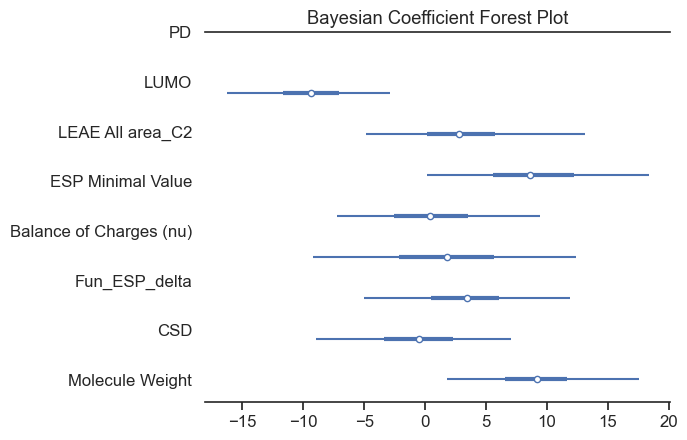

In [12]:
# -----------------------------
# Posterior plot
# -----------------------------
fig, axes = plt.subplots(len(trace.posterior["beta"].values.T) + 1, 1, figsize=(6, 7 * 3))  # 每个参数一个子图
for i, ax in enumerate(axes[:-1]):
    az.plot_posterior(trace.posterior["beta"][:, :, i], ax=ax)
    ax.set_title(f"beta[{i}] Posterior Distribution ({feature_names[i]})")

# intercept
az.plot_posterior(trace.posterior["intercept"], ax=axes[-1])
axes[-1].set_title("Intercept Posterior Distribution (Intercept)")

plt.tight_layout()
plt.show()


# -----------------------------
# Forest plot
# -----------------------------
az.plot_forest(
    trace_full,
    var_names=["beta"],
    combined=True,
    hdi_prob=0.95
)

plt.yticks(range(len(feature_names)), feature_names)
plt.title("Bayesian Coefficient Forest Plot")
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]


/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 5 seconds.
There were 1166 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


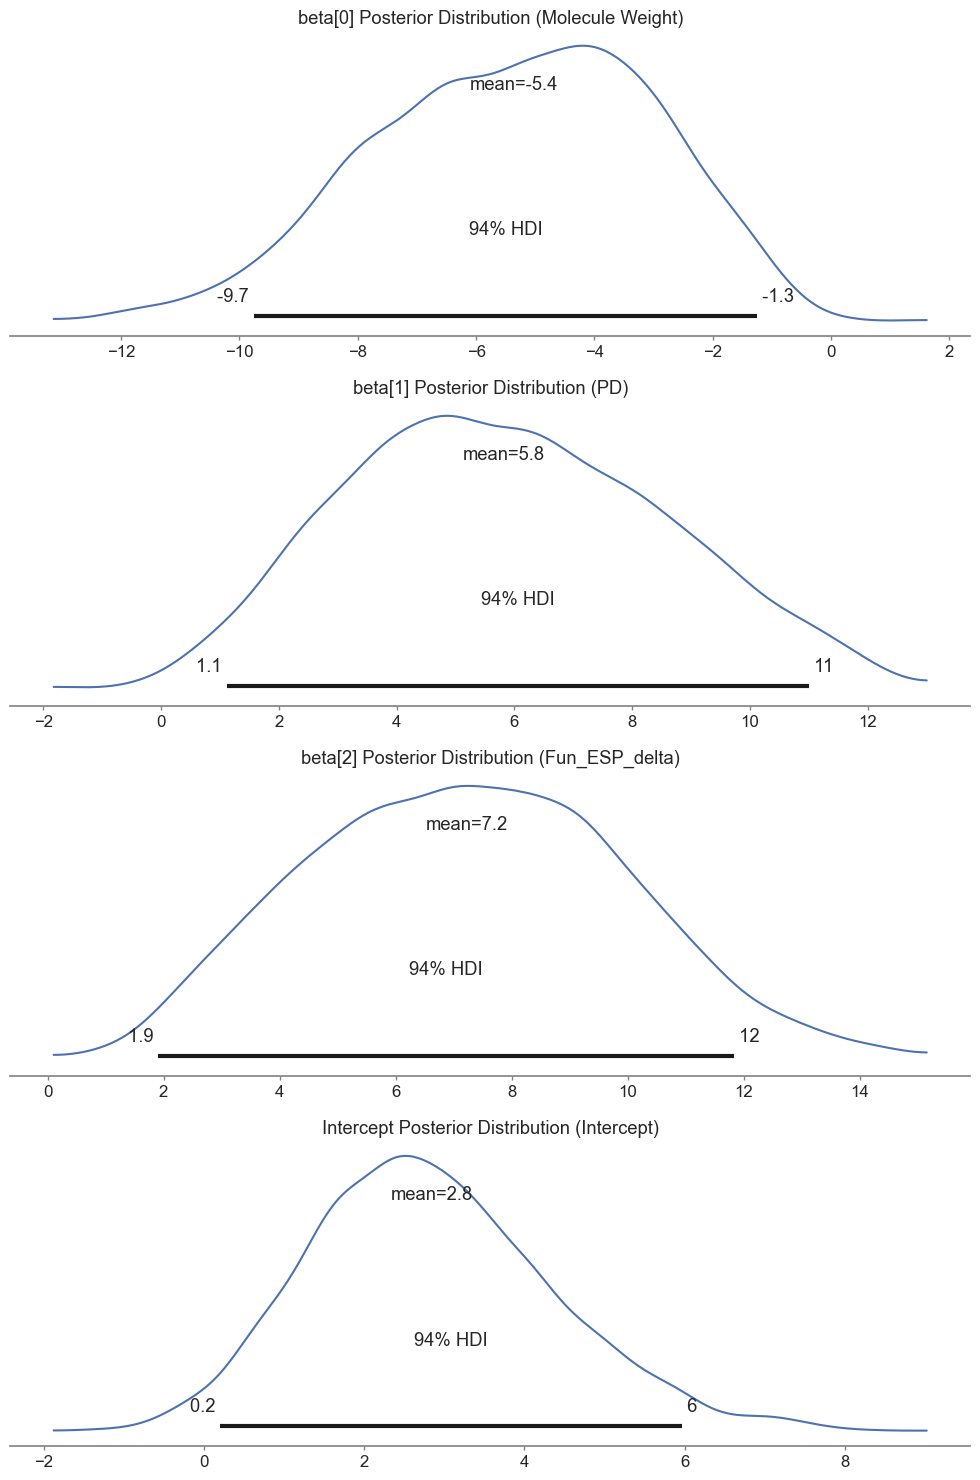

Sampling: [observed]


/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Accuracy: 0.9444444444444444
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.92      1.00      0.96        11

    accuracy                           0.94        18
   macro avg       0.96      0.93      0.94        18
weighted avg       0.95      0.94      0.94        18



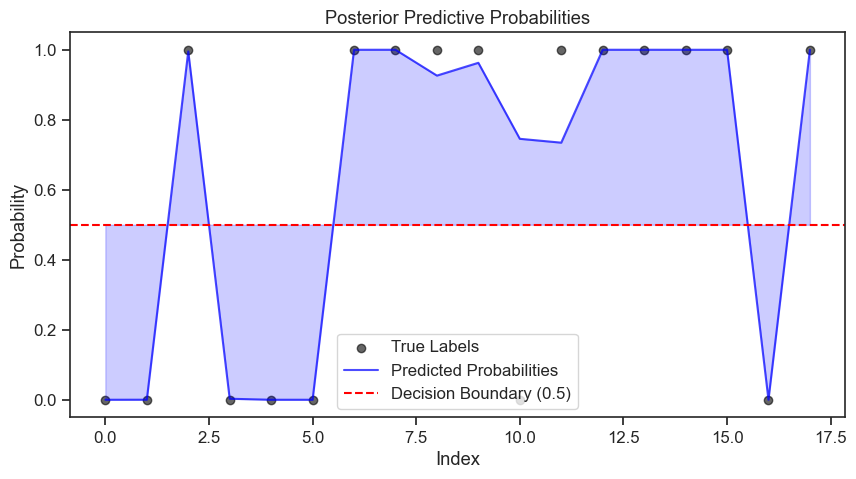

<Figure size 600x600 with 0 Axes>

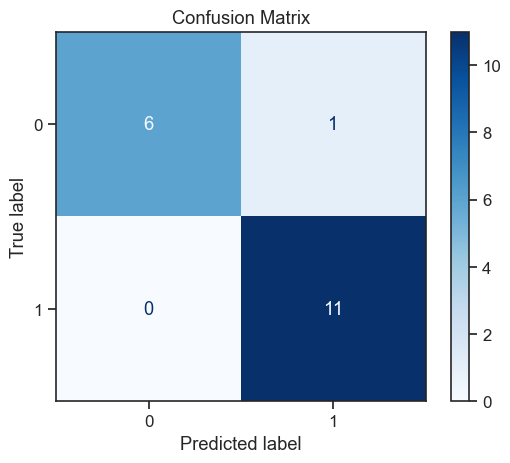

In [13]:
Selected_columns = ['Molecule Weight', 'PD', 'Fun_ESP_delta']
X_select = X_df[Selected_columns].copy()


with pm.Model() as bayesian_logistic_model:
    # 
    beta = pm.Normal("beta", mu=0, sigma=10, shape=X_select.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=10)
    
    # 
    linear_combination = pm.math.dot(X_select.values, beta) + intercept
    
    #  sigmoid
    p = pm.Deterministic("p", pm.math.sigmoid(linear_combination))
    
    # 
    observed = pm.Bernoulli("observed", p=p, observed=y.values)
    
    # 
    trace = pm.sample(1000, tune=2000, target_accept=0.95, random_seed=42)


variable_names = X_select.columns.tolist()

fig, axes = plt.subplots(len(trace.posterior["beta"].values.T) + 1, 1, figsize=(10, 15))  # 每个参数一个子图
for i, ax in enumerate(axes[:-1]):
    az.plot_posterior(trace.posterior["beta"][:, :, i], ax=ax)
    # 
    ax.set_title(f"beta[{i}] Posterior Distribution ({variable_names[i]})")

# intercept
az.plot_posterior(trace.posterior["intercept"], ax=axes[-1])
axes[-1].set_title("Intercept Posterior Distribution (Intercept)")

plt.tight_layout()
plt.show()


with bayesian_logistic_model:
    posterior_predictive = pm.sample_posterior_predictive(trace)
    

beta_samples = trace.posterior["beta"].mean(axis=(0, 1)).values
intercept_sample = trace.posterior["intercept"].mean(axis=(0, 1)).values


linear_combination = np.dot(X_select.values, beta_samples) + intercept_sample
pred_mean = 1 / (1 + np.exp(-linear_combination))  # Sigmoid
y_pred = (pred_mean > 0.5).astype(int)


accuracy = accuracy_score(y.values, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y.values, y_pred))


plt.figure(figsize=(10, 5))
plt.scatter(np.arange(len(y)), y, label="True Labels", alpha=0.6, color="black")
plt.plot(np.arange(len(y)), pred_mean, label="Predicted Probabilities", alpha=0.7, color="blue")
plt.axhline(0.5, linestyle="--", color="red", label="Decision Boundary (0.5)")
plt.fill_between(np.arange(len(y)), 0.5, pred_mean, alpha=0.2, color="blue")
plt.legend()
plt.xlabel("Index")
plt.ylabel("Probability")
plt.title("Posterior Predictive Probabilities")
plt.show()

cm = confusion_matrix(y.values, y_pred)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [19]:
RANDOM_STATE = 42
# =========================
# Models
# =========================
model_dict = {
    "LR": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "RF": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "DT": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

# =========================
# Utility
# =========================
def build_model(base_model, model_name):
    if model_name in ["LR", "SVM"]:
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", clone(base_model))
        ])
    else:
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", clone(base_model))
        ])
def get_score(model, X):
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)
        if p.ndim == 2 and p.shape[1] >= 2:
            return p[:, 1]
        elif p.ndim == 1:
            return p
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

def calc_metrics(y_true, y_pred, y_score):
    return {
        "AUC": roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan,
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0)
    }
    
# =========================
# LOOCV evaluation
# =========================
def loocv_eval_models(X, y, feature_list, model_dict):
    X_sub = X[feature_list].copy()
    y = np.asarray(y)
    loo = LeaveOneOut()
    results = {}
    for model_name, base_model in model_dict.items():
        y_true_all = []
        y_pred_all = []
        y_score_all = []
        for tr_idx, te_idx in loo.split(X_sub, y):
            X_train, X_test = X_sub.iloc[tr_idx], X_sub.iloc[te_idx]
            y_train, y_test = y[tr_idx], y[te_idx]
            model = build_model(base_model, model_name)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)[0]
            y_score = get_score(model, X_test)
            y_score = y_score[0] if y_score is not None else np.nan
            y_true_all.append(y_test[0])
            y_pred_all.append(y_pred)
            y_score_all.append(y_score)
        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)
        y_score_all = np.array(y_score_all, dtype=float)
        metrics = calc_metrics(y_true_all, y_pred_all, y_score_all)
        results[model_name] = {
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "y_score": y_score_all,
            "metrics": metrics
        }
    return results

# =========================
# Permutation test
# =========================
def permutation_test_loocv_auc(X, y, feature_list, model_name, base_model,
                               n_permutations=1000, random_state=42):
    rng = np.random.RandomState(random_state)
    # observed
    obs_res = loocv_eval_models(X, y, feature_list, {model_name: base_model})
    observed_auc = obs_res[model_name]["metrics"]["AUC"]
    perm_aucs = []
    for i in range(n_permutations):
        y_perm = rng.permutation(y)
        perm_res = loocv_eval_models(X, y_perm, feature_list, {model_name: base_model})
        perm_auc = perm_res[model_name]["metrics"]["AUC"]
        perm_aucs.append(perm_auc)
    perm_aucs = np.array(perm_aucs, dtype=float)
    p_value = (np.sum(perm_aucs >= observed_auc) + 1) / (len(perm_aucs) + 1)
    return {
        "observed_auc": observed_auc,
        "perm_aucs": perm_aucs,
        "p_value": p_value
    }
    
# =========================
# Plot ROC panel
# =========================
def plot_roc_panel(results):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()
    colors = {
        "LR": "#1f77b4",
        "SVM": "#d62728",
        "RF": "#2ca02c",
        "DT": "#9467bd"
    }
    for ax, (model_name, res) in zip(axes, results.items()):
        y_true = res["y_true"]
        y_score = res["y_score"]
        auc_value = res["metrics"]["AUC"]
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ax.plot(fpr, tpr, color=colors.get(model_name, "black"),
                lw=2.5, label=f"AUC = {auc_value:.3f}")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.2)
        ax.set_title(model_name, fontsize=18, fontweight="bold")
        ax.set_xlabel("False Positive Rate", fontsize=16)
        ax.set_ylabel("True Positive Rate",  fontsize=16)
        ax.legend(frameon=False, loc="lower right", fontsize=14)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
    plt.tight_layout()
    fig.savefig("./fig/clf_roc.pdf", dpi=330)
    fig.savefig("./fig/clf_roc.svg", dpi=330)
    plt.show()
    
# =========================
# Plot confusion matrices
# =========================
def plot_confusion_panel(results):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()
    tick_lables = ['low', 'high']
    for ax, (model_name, res) in zip(axes, results.items()):

        cm = confusion_matrix(res["y_true"], res["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, xticklabels=tick_lables, yticklabels=tick_lables, ax=ax, annot_kws={
            "fontsize":14
        })
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=14)
        ax.set_title(model_name, fontsize=18, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=16)
        ax.set_ylabel("True", fontsize=16)
    plt.tight_layout()
    fig.savefig("./fig/clf_confusion.pdf", dpi=330)
    fig.savefig("./fig/clf_confusion.svg", dpi=330)
    plt.show()
    
# =========================
# Plot permutation histograms
# =========================
def plot_permutation_panel(perm_results):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()
    colors = {
        "LR": "#1f77b4",
        "SVM": "#d62728",
        "RF": "#2ca02c",
        "DT": "#9467bd"
    }
    for ax, (model_name, res) in zip(axes, perm_results.items()):
        sns.histplot(res["perm_aucs"], bins=30, kde=True,
                     color=colors.get(model_name, "gray"), ax=ax)
        ax.axvline(res["observed_auc"], color="black", linestyle="--", lw=2,
                   label=f"Observed AUC = {res['observed_auc']:.3f}")
        ax.set_title(f"{model_name} (p = {res['p_value']:.4f})",
                     fontsize=16, fontweight="bold")
        ax.set_xlabel("Permuted AUC", fontsize=16)
        ax.set_ylabel("Count", fontsize=16)
        ax.legend(frameon=False, fontsize=14)
    plt.tight_layout()
    fig.savefig("./fig/clf_permutation.pdf", dpi=330)
    fig.savefig("./fig/clf_permutation.svg", dpi=330)
    plt.show()
    
# =========================
# Summary table
# =========================
def make_summary_table(results, perm_results=None):
    rows = []
    for model_name, res in results.items():
        row = {"Model": model_name}
        row.update(res["metrics"])
        if perm_results is not None and model_name in perm_results:
            row["Permutation p-value"] = perm_results[model_name]["p_value"]
        rows.append(row)
    summary_df = pd.DataFrame(rows)
    summary_df = summary_df.sort_values(by=["AUC", "Balanced Accuracy", "MCC"],
                                        ascending=False).reset_index(drop=True)
    return summary_df

In [15]:
final_features = ['Molecule Weight', 'PD', 'Fun_ESP_delta']
X = X_df[final_features].copy()

# 1. LOOCV评估四模型
results = loocv_eval_models(X, y, final_features, model_dict)

# 2. permutation test
perm_results = {}
for model_name, base_model in model_dict.items():
    print(f"Running permutation test for {model_name}...")
    perm_results[model_name] = permutation_test_loocv_auc(
        X, y, final_features,
        model_name, base_model,
        n_permutations=1000,
        random_state=42
    )

# 3. summary table
summary_df = make_summary_table(results, perm_results)
display(summary_df)

Running permutation test for LR...
Running permutation test for SVM...
Running permutation test for RF...
Running permutation test for DT...


,Model,AUC,Balanced Accuracy,MCC,Accuracy,F1,Precision,Recall,Permutation p-value
0,LR,0.961039,0.883117,0.766234,0.888889,0.909091,0.909091,0.909091,0.001998
1,SVM,0.948052,0.837662,0.662541,0.833333,0.857143,0.900000,0.818182,0.016983
2,RF,0.922078,0.740260,0.522998,0.777778,0.833333,0.769231,0.909091,0.004995
3,DT,0.792208,0.792208,0.569803,0.777778,0.800000,0.888889,0.727273,0.027972


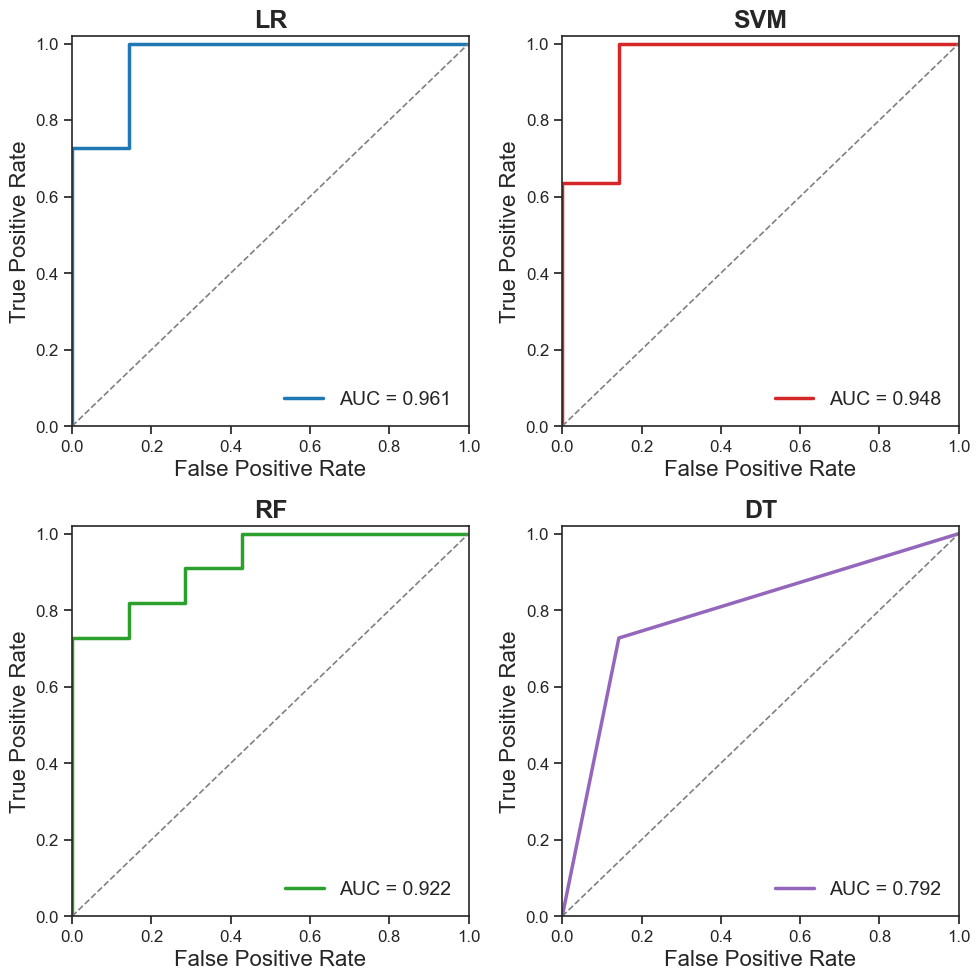

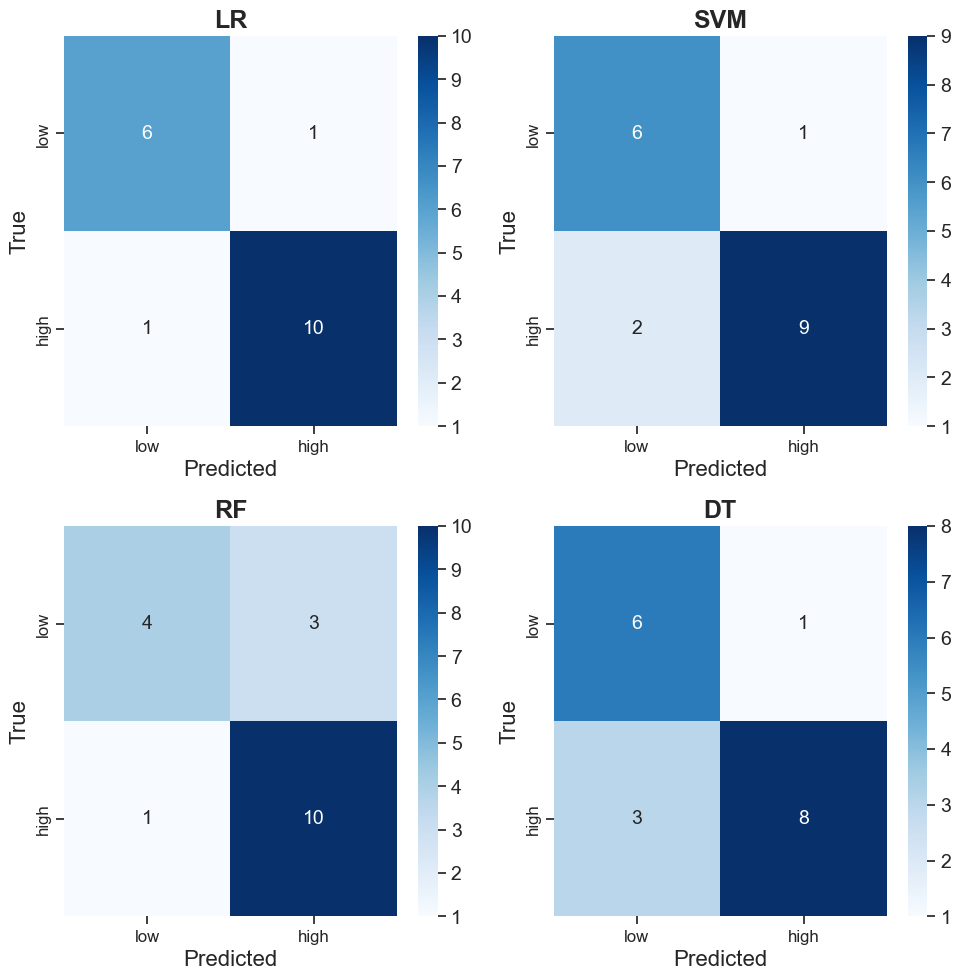

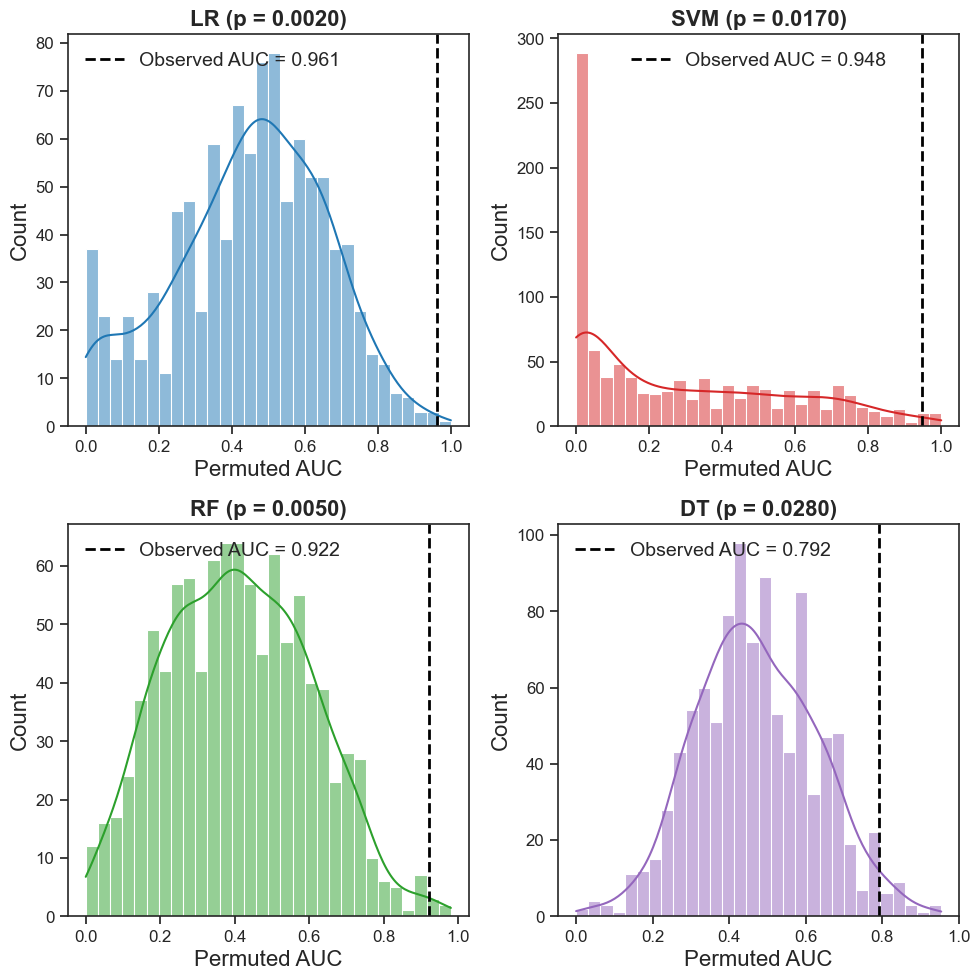

In [20]:

# 4. plots
sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['mathtext.default'] = 'regular'

plot_roc_panel(results)
plot_confusion_panel(results)
plot_permutation_panel(perm_results)